In [ ]:
!git clone https://github.com/DepthAnything/Depth-Anything-V2
!wget -O depth_anything_v2_vits.pth https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth?download=true
# !wget -O depth_anything_v2_vits.pth https://huggingface.co/depth-anything/Depth-Anything-V2-Base/resolve/main/depth_anything_v2_vitb.pth?download=true

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import cv2
import random
import h5py

import sys
sys.path.append('/kaggle/working/Depth-Anything-V2/metric_depth')

from accelerate import Accelerator
from accelerate.utils import set_seed
from accelerate import notebook_launcher
from accelerate import DistributedDataParallelKwargs

import transformers

import torch
import torchvision
from torchvision.transforms import v2
from torchvision.transforms import Compose
import torch.nn.functional as F
import albumentations as A

from depth_anything_v2.dpt import DepthAnythingV2
from util.loss import SiLogLoss
from dataset.transform import Resize, NormalizeImage, PrepareForNet, Crop

### List of paths

In [ ]:
def get_all_files(dir_path):
    files = os.listdir(dir_path)
    depth_files = {f.split('_depth')[0]: os.path.join(dir_path, f) for f in files if f.endswith('_depth.npy')}
    rgb_files = {f.split('_rgb')[0]: os.path.join(dir_path, f) for f in files if f.endswith('_rgb.png')}

    pairs = [(rgb_files[k], depth_files[k]) for k in depth_files if k in rgb_files]
    return pairs

all_paths = get_all_files('/kaggle/input/ethz-cil-monocular-depth-estimation-2025/train/train')
mid = round(len(all_paths)*0.9)
train_paths = all_paths[:mid]
val_paths = all_paths[mid:]

# Dataset preparation

In [ ]:
from PIL import Image
#NYU Depth V2 40k. Original NYU is 400k
class NYU(torch.utils.data.Dataset):
    def __init__(self, paths, mode, size=(518, 518)):
        
        self.mode = mode #train or val
        self.size = size
        self.paths = paths
        
        net_w, net_h = size
        #author's transforms
        self.transform = Compose([
            Resize(
                width=net_w,
                height=net_h,
                resize_target=True if mode == 'train' else False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method='lower_bound',
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ] + ([Crop(size[0])] if self.mode == 'train' else []))
        
        # only horizontal flip in the paper
        self.augs = A.Compose([
            A.HorizontalFlip(),
            A.ColorJitter(hue = 0.1, contrast=0.1, brightness=0.1, saturation=0.1),
            A.GaussNoise(var_limit=25),
#             A.ShiftScaleRotate(shift_limit=0.04, scale_limit=0.1, rotate_limit=7, interpolation=cv2.INTER_CUBIC, border_mode=0)
        ])
    
    def __getitem__(self, item):
        image_path, depth_path = self.paths[item]
        image = np.array(Image.open(image_path))
        depth = np.load(depth_path)
        
        if self.mode == 'train':
            augmented = self.augs(image=image, mask = depth)
            image = augmented["image"] / 255.0
            depth = augmented['mask']
        else:
            image = image / 255.0

          
        sample = self.transform({'image': image, 'depth': depth})

        sample['image'] = torch.from_numpy(sample['image'])
        sample['depth'] = torch.from_numpy(sample['depth'])
        
        # sometimes there are masks for valid depths in datasets because of noise e.t.c
#         sample['valid_mask'] = ...

#         sample['image_path'] = path
        
        return sample

    def __len__(self):
        return len(self.paths)
    
    def h5_loader(self, path):
        h5f = h5py.File(path, "r")
        rgb = np.array(h5f['rgb'])
        rgb = np.transpose(rgb, (1, 2, 0))
        depth = np.array(h5f['depth'])
        return rgb, depth

# Dataset demonstration

In [ ]:
num_images = 5

fig, axes = plt.subplots(num_images, 2, figsize=(10, 5 * num_images))

train_set = NYU(train_paths, mode='train') 

for i in range(num_images):
    sample = train_set[i*1000]
    img, depth = sample['image'].numpy(), sample['depth'].numpy()

    mean = np.array([0.485, 0.456, 0.406]).reshape((3, 1, 1))
    std = np.array([0.229, 0.224, 0.225]).reshape((3, 1, 1))
    img = img*std+mean

    axes[i, 0].imshow(np.transpose(img, (1,2,0)))
    axes[i, 0].set_title('Image')
    axes[i, 0].axis('off')


    im1 = axes[i, 1].imshow(depth, cmap='viridis', vmin=0)
    axes[i, 1].set_title('True Depth')
    axes[i, 1].axis('off')
    fig.colorbar(im1, ax=axes[i, 1])
    


plt.tight_layout()


### Very blurry and noisy images. Also, there are a lot of almost identical pictures

In [ ]:
def get_dataloaders(batch_size):
    
    train_dataset = NYU(train_paths, mode='train')
    val_dataset = NYU(val_paths, mode='val') 
    
    
    train_dataloader = torch.utils.data.DataLoader(train_dataset, 
                                                  batch_size = batch_size,
                                                  shuffle=True,
                                                  num_workers=4,
                                                  drop_last=True
#                                                   pin_memory=True
                                                  )

    val_dataloader = torch.utils.data.DataLoader(val_dataset, 
                                               batch_size = 1, #for dynamic resolution evaluations without padding
                                               shuffle=False,
                                               num_workers=4,
                                               drop_last=True
#                                                 pin_memory=True
                                                )
    
    return train_dataloader, val_dataloader

# Metrics function

In [ ]:
def eval_depth(pred, target):
    assert pred.shape == target.shape

    thresh = torch.max((target / pred), (pred / target))

    d1 = torch.sum(thresh < 1.25).float() / len(thresh)

    diff = pred - target
    diff_log = torch.log(pred) - torch.log(target)

    abs_rel = torch.mean(torch.abs(diff) / target)

    rmse = torch.sqrt(torch.mean(torch.pow(diff, 2)))
    mae = torch.mean(torch.abs(diff))

    silog = torch.sqrt(torch.pow(diff_log, 2).mean() - 0.5 * torch.pow(diff_log.mean(), 2))

    return {'d1': d1.detach(), 'abs_rel': abs_rel.detach(),'rmse': rmse.detach(), 'mae': mae.detach(), 'silog':silog.detach()}

# Training

In [ ]:
model_weights_path =  '/kaggle/working/depth_anything_v2_vits.pth' 
model_configs = {
        'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
        'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
        'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
        'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
    }
model_encoder = 'vits'
max_depth = 10
batch_size = 11
lr = 5e-6
weight_decay = 0.01
num_epochs = 10
warmup_epochs = 0.5
scheduler_rate = 1
load_state = False

state_path = "/kaggle/working/cp"
save_model_path = '/kaggle/working/model'
seed = 42
mixed_precision = 'fp16'

In [ ]:
def train_fn():

    set_seed(seed)
    ddp_kwargs = DistributedDataParallelKwargs(find_unused_parameters=True) # need for freezing layers with DDP
    accelerator = Accelerator(mixed_precision=mixed_precision, 
                              kwargs_handlers=[ddp_kwargs],
                             )
    
    # in the paper they initialize decoder randomly and use only encoder pretrained weights. Then full fine-tune
    # ViT-S encoder here
    model = DepthAnythingV2(**{**model_configs[model_encoder], 'max_depth': max_depth})
    model.load_state_dict({k: v for k, v in torch.load(model_weights_path).items() if 'pretrained' in k}, strict=False)
    
    optim = torch.optim.AdamW([{'params': [param for name, param in model.named_parameters() if 'pretrained' in name], 'lr': lr},
                       {'params': [param for name, param in model.named_parameters() if 'pretrained' not in name], 'lr': lr*10}],
                      lr=lr, weight_decay=weight_decay)
    
    criterion = SiLogLoss() # author's loss
    
    train_dataloader, val_dataloader = get_dataloaders(batch_size)
    
    scheduler = transformers.get_cosine_schedule_with_warmup(optim, len(train_dataloader)*warmup_epochs, num_epochs*scheduler_rate*len(train_dataloader))
    
    model, optim, train_dataloader, val_dataloader, scheduler = accelerator.prepare(model, optim, train_dataloader, val_dataloader, scheduler)
    
    
    if load_state:
        accelerator.wait_for_everyone()
        accelerator.load_state(state_path)
        
    best_val_absrel = 1000
    
    
    for epoch in range(1, num_epochs):
        
        model.train()
        train_loss = 0
        for sample in tqdm(train_dataloader, disable = not accelerator.is_local_main_process):
            optim.zero_grad()
            
            img, depth = sample['image'], sample['depth']
            
            pred = model(img) 
                                                     # mask
            loss = criterion(pred, depth, (depth <= max_depth) & (depth >= 0.001))
            
            accelerator.backward(loss)
            optim.step()
            scheduler.step()
            
            train_loss += loss.detach()
            
            
            
        train_loss /= len(train_dataloader)
        train_loss = accelerator.reduce(train_loss, reduction='mean').item()
        
        
        model.eval()
        results = {'d1': 0, 'abs_rel': 0,'rmse': 0, 'mae': 0, 'silog': 0}
        for sample in tqdm(val_dataloader, disable = not accelerator.is_local_main_process):
            
            img, depth = sample['image'].float(), sample['depth'][0]
            
            with torch.no_grad():
                pred = model(img)
                # evaluate on the original resolution 
                pred = F.interpolate(pred[:, None], depth.shape[-2:], mode='bilinear', align_corners=True)[0, 0]
            
            valid_mask = (depth <= max_depth) & (depth >= 0.001)
            
            cur_results = eval_depth(pred[valid_mask], depth[valid_mask])
            
            for k in results.keys():
                results[k] += cur_results[k]
            

        for k in results.keys():
            results[k] = results[k] / len(val_dataloader)
            results[k] = round(accelerator.reduce(results[k], reduction='mean').item(),3)
        
        
        accelerator.wait_for_everyone()
        accelerator.save_state(state_path, safe_serialization=False)
        
        if results['abs_rel'] < best_val_absrel:
            best_val_absrel = results['abs_rel']
            unwrapped_model = accelerator.unwrap_model(model)
            if accelerator.is_local_main_process:
                torch.save(unwrapped_model.state_dict(), save_model_path)
        
        accelerator.print(f"epoch_{epoch},  train_loss = {train_loss:.5f}, val_metrics = {results}")
        
#P.S. While testing one configuration, I encountered an error in which the loss turned into nan. 
# This is fixed by adding a small epsilon to the predictions to prevent division by 0

In [ ]:
#You can run this code with 1 gpu. Just set num_processes=1
notebook_launcher(train_fn, num_processes=2)
# ignore the error. it's harmless

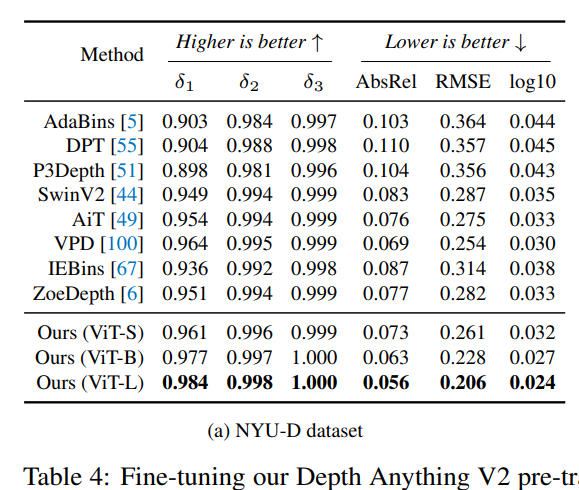



### The difference of 2-3 percent with this scores (ViT-S) from the paper is explained in the different volume of the dataset (40k vs 400k)

https://arxiv.org/abs/2406.09414

# Inference
## Reminder: This is ABSOLUTE (metric) depth, not a relative depth!!

In [ ]:
model = DepthAnythingV2(**{**model_configs[model_encoder], 'max_depth': max_depth}).to('cuda')
model.load_state_dict(torch.load(save_model_path))

In [ ]:
num_images = 10

fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))

val_dataset = NYU(val_paths, mode='val') 
model.eval()
for i in range(num_images):
    sample = val_dataset[i]
    img, depth = sample['image'], sample['depth']
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
   
    with torch.inference_mode():
        pred = model(img.unsqueeze(0).to('cuda'))
        pred = F.interpolate(pred[:, None], depth.shape[-2:], mode='bilinear', align_corners=True)[0, 0]
            
    img = img*std + mean
     
    axes[i, 0].imshow(img.permute(1,2,0))
    axes[i, 0].set_title('Image')
    axes[i, 0].axis('off')

    max_depth = max(depth.max(), pred.cpu().max())
    
    im1 = axes[i, 1].imshow(depth, cmap='viridis', vmin=0, vmax=max_depth)
    axes[i, 1].set_title('True Depth')
    axes[i, 1].axis('off')
    fig.colorbar(im1, ax=axes[i, 1])
    
    im2 = axes[i, 2].imshow(pred.cpu(), cmap='viridis', vmin=0, vmax=max_depth)
    axes[i, 2].set_title('Predicted Depth')
    axes[i, 2].axis('off')
    fig.colorbar(im2, ax=axes[i, 2])

plt.tight_layout()



In [ ]:
import torchvision.transforms as transforms

test_path = "/kaggle/input/ethz-cil-monocular-depth-estimation-2025/test/test"
target_dir = "/kaggle/working/results/"
os.makedirs(target_dir, exist_ok=True)

files = os.listdir(test_path)
transform_pipeline = transforms.Compose([
    transforms.Resize((518, 518), interpolation=transforms.InterpolationMode.BILINEAR, antialias=True),
    transforms.ToTensor(),         
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])
original_size_hw = (426, 560)

for path in files:
    img = transform_pipeline(Image.open(os.path.join(test_path, path)))
    
    with torch.inference_mode():
        pred = model(img.unsqueeze(0).to('cuda'))
        pred = F.interpolate(
            pred.unsqueeze(0),  
            size=original_size_hw,               
            mode='bilinear',
            align_corners=False
        )
        
        np.save(os.path.join("/kaggle/working/results/", path.replace("rgb.png", "depth.npy")), pred.cpu().numpy())
            
    
    

In [ ]:
# Copied over from create_prediction_csv.py

mport os
import numpy as np
import pandas as pd
import base64
import zlib
from tqdm import tqdm

# Path definitions
predictions_dir = "/kaggle/working/results"
test_list_file = "/kaggle/input/ethz-cil-monocular-depth-estimation-2025/test_list.txt"
output_csv = "/kaggle/working/predictions.csv"

def compress_depth_values(depth_values):
    # Convert depth values to bytes
    depth_bytes = ','.join(f"{x:.2f}" for x in depth_values).encode('utf-8')
    # Compress using zlib
    compressed = zlib.compress(depth_bytes, level=9)  # level 9 is maximum compression
    # Encode as base64 for safe CSV storage
    return base64.b64encode(compressed).decode('utf-8')

def process_depth_maps():
    # Read file list
    with open(test_list_file, 'r') as f:
        file_pairs = [line.strip().split() for line in f]
    
    # Initialize lists to store data
    ids = []
    depths_list = []
    
    # Process each depth map
    for rgb_path, depth_path in tqdm(file_pairs, desc="Processing depth maps"):
        # Get file ID (without extension)
        file_id = os.path.splitext(os.path.basename(depth_path))[0]
        
        # Load depth map
        depth = np.load(os.path.join(predictions_dir, depth_path))
        # Flatten the depth map and round to two decimal points
        flattened_depth = np.round(depth.flatten(), 2)
        
        # Compress the depth values
        compressed_depths = compress_depth_values(flattened_depth)
        ids.append(file_id)
        depths_list.append(compressed_depths)

    # Create DataFrame
    df = pd.DataFrame({
        'id': ids,
        'Depths': depths_list,
    })
    
    # Save to CSV
    df.to_csv(output_csv, index=False)
    print(f"CSV file saved to: {output_csv}")
    print(f"Shape of the CSV: {df.shape}")
    

process_depth_maps() 

# Helpful papers
* https://arxiv.org/abs/1907.01341 (Midas)
* https://arxiv.org/abs/2103.13413 (DPT)
* https://arxiv.org/abs/2302.12288 (ZoeDepth)
* https://arxiv.org/abs/2401.10891 (Depth Anything V1)
* https://arxiv.org/abs/2406.09414 (Depth Anything V2)